# Técnicas de balanceo


Nuestra variable objetivo no cuenta con un desbalanceo evidente, sin embargo aplicaremos las tecnicas de balanceo por efectos academicos y por el cumplimiento de los requerimientos del taller. Además por temas de tiempo solo utilizaremos los 3 modelos con mejor score vistos en el benchmark

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [84]:
# Cargar dataset (ajusta la ruta si es necesario)
df = pd.read_csv('data/raw/diabetic_data.csv')

# Crear la variable objetivo 'target'
df['target'] = df['readmitted'].isin(['<30', '>30']).astype(int)
df.drop(columns=['readmitted'], inplace=True)

# Ver distribución de clases
proportion = df['target'].value_counts(normalize=True)
count = df['target'].value_counts()

print("Distribución de clases:\n", proportion)
print("\nConteo absoluto:\n", count)



Distribución de clases:
 target
0    0.539119
1    0.460881
Name: proportion, dtype: float64

Conteo absoluto:
 target
0    54864
1    46902
Name: count, dtype: int64


In [85]:
# ===============================
# Identificar y codificar variables categóricas
# ===============================
cat_cols = df.select_dtypes(include=['object']).columns
print("Columnas categóricas:", list(cat_cols))

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ===============================
# Limpiar nombres de columnas después del encoding
# ===============================
df_encoded.columns = (
    df_encoded.columns
      .astype(str)
      .str.replace('[', '(', regex=False)
      .str.replace(']', ')', regex=False)
      .str.replace('<', 'menor_', regex=False)
      .str.replace('>', 'mayor_', regex=False)
      .str.replace('=', '_', regex=False)
      .str.replace(':', '_', regex=False)
      .str.replace(',', '_', regex=False)
      .str.replace(' ', '_', regex=False)
)


# ===============================
# Sustituir el dataframe original
# ===============================
df = df_encoded

print("Dimensiones después del encoding:", df.shape)




Columnas categóricas: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Dimensiones después del encoding: (101766, 2435)


In [86]:
# ===============================
# 4️⃣ Separar X e y
# ===============================
X = df.drop(columns=['target'])
y = df['target']

# ===============================
# 5️⃣ División de datos
# ===============================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño del set de entrenamiento:", X_train.shape)
print("Tamaño del set de prueba:", X_test.shape)


Tamaño del set de entrenamiento: (71236, 2434)
Tamaño del set de prueba: (30530, 2434)


In [ ]:



def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    return {
        'Modelo': nombre,
        'Accuracy': round(acc, 3),
        'F1-score': round(f1, 3),
        'AUC': round(auc, 3)
    }


In [ ]:
resultados = []

modelos = [
    (GaussianNB(), "Naive Bayes"),
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "XGBoost")
]

for modelo, nombre in modelos:
    res = evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre + " (Original)")
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
df_resultados


c:\Users\camil\anaconda3\envs\ML_VENV\lib\site-packages\xgboost\core.py:158: UserWarning: [19:31:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Modelo,Accuracy,F1-score,AUC
0,Naive Bayes (Original),0.577,0.434,0.586
1,Random Forest (Original),0.660,0.598,0.718
2,XGBoost (Original),0.672,0.632,0.734


## SMOTE

Con el fin de explorar técnicas de manejo de desbalance en la variable objetivo, se aplicó el método **SMOTE (Synthetic Minority Over-sampling Technique)** al conjunto de entrenamiento. Este algoritmo genera nuevas instancias sintéticas de la clase minoritaria mediante interpolación entre observaciones cercanas, buscando igualar la cantidad de ejemplos entre ambas clases.  

En este caso, el dataset original presentaba una distribución ligeramente desbalanceada (≈54% clase 0 y 46% clase 1), lo cual no afecta significativamente el rendimiento de la mayoría de los modelos. Sin embargo, **se aplicó SMOTE únicamente con fines académicos** para observar cómo el balance artificial de las clases impacta las métricas de desempeño.


In [89]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribución tras SMOTE:")
print(pd.Series(y_train_sm).value_counts(normalize=True))

# Evaluar con datos balanceados
for modelo, nombre in modelos:
    res = evaluar_modelo(modelo, X_train_sm, X_test, y_train_sm, y_test, nombre + " (SMOTE)")
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
df_resultados


c:\Users\camil\anaconda3\envs\ML_VENV\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Distribución tras SMOTE:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


c:\Users\camil\anaconda3\envs\ML_VENV\lib\site-packages\xgboost\core.py:158: UserWarning: [19:35:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Modelo,Accuracy,F1-score,AUC
0,Naive Bayes (Original),0.577,0.434,0.586
1,Random Forest (Original),0.660,0.598,0.718
2,XGBoost (Original),0.672,0.632,0.734
3,Naive Bayes (SMOTE),0.565,0.574,0.586
4,Random Forest (SMOTE),0.656,0.622,0.712
5,XGBoost (SMOTE),0.666,0.635,0.729


- El balanceo con SMOTE **no incrementó significativamente la precisión (Accuracy)** en ninguno de los modelos, lo cual es esperable ya que el dataset original no estaba fuertemente desbalanceado o el modelo ya manejaba bien la clase minoritaria.  
- Sin embargo, el **F1-score mejora en el Naive Bayes**, lo que indica un **mejor equilibrio entre precisión y sensibilidad** tras el balanceo. Esto sugiere que SMOTE ayudó a que el modelo reconozca más casos positivos, reduciendo falsos negativos.  
- En los modelos más complejos (**Random Forest** y **XGBoost**), las métricas se mantienen casi iguales, con **ligeras variaciones en el F1-score y el AUC**, lo que refleja una **mayor estabilidad y robustez** frente al desbalance.  
- El **AUC** se mantiene prácticamente estable, lo que indica que la capacidad discriminativa de los modelos **no se vio afectada** por el uso de datos sintéticos.

## class weight=’balanced’

Cada modelo fue entrenado y evaluado utilizando la misma partición de datos (`X_train`, `X_test`, `y_train`, `y_test`).  
Las métricas consideradas fueron **Accuracy**, **F1-score** y **AUC (Área Bajo la Curva ROC)**, que permiten evaluar tanto el rendimiento general como la capacidad del modelo para distinguir entre clases.

Naive Bayes no fue implementado pues no acepta la 'class weight = 'balanced'


In [ ]:
# Calcular el peso de balanceo
neg, pos = np.bincount(y_train)
scale = neg / pos

xgb_balanced = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale
)

modelos_balanced = [
    (RandomForestClassifier(class_weight='balanced', random_state=42), "Random Forest (CW)"),
    (xgb_balanced, "XGBoost (CW)")
]

for modelo, nombre in modelos_balanced:
    res = evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre)
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
df_resultados


c:\Users\camil\anaconda3\envs\ML_VENV\lib\site-packages\xgboost\core.py:158: UserWarning: [19:38:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Modelo,Accuracy,F1-score,AUC
0,Naive Bayes (Original),0.577,0.434,0.586
1,Random Forest (Original),0.660,0.598,0.718
2,XGBoost (Original),0.672,0.632,0.734
3,Naive Bayes (SMOTE),0.565,0.574,0.586
4,Random Forest (SMOTE),0.656,0.622,0.712
5,XGBoost (SMOTE),0.666,0.635,0.729
6,Random Forest (CW),0.663,0.602,0.719
7,XGBoost (CW),0.668,0.651,0.733


- **Efectividad del balanceo por pesos (`class_weight`)**  
   Los modelos con `class_weight='balanced'` lograron **rendimientos similares o ligeramente superiores** a sus versiones originales, especialmente en el **F1-score**, lo que sugiere una mejora en la capacidad de detección de la clase minoritaria sin pérdida significativa de precisión general.

- **Comparación con SMOTE**  
   En comparación con el sobremuestreo sintético (SMOTE), el balanceo por pesos fue **más eficiente computacionalmente** y produjo resultados muy cercanos en las métricas principales. Esto demuestra que `class_weight` puede ser una alternativa viable cuando los recursos de memoria son limitados o el dataset es grande.

- **XGBoost y Random Forest mantienen su liderazgo**  
   Como en los experimentos previos, **XGBoost (CW)** sigue siendo el modelo con mejor rendimiento general (AUC = 0.733), confirmando su solidez y estabilidad incluso con ajustes de balanceo de clases.

## ADASYN

Intentamos aplicar ADASYN para balancear la variable objetivo; sin embargo, el dataset presenta una distribución muy cercana al equilibrio (54% vs 46%), por lo que el algoritmo no generó nuevas instancias.

In [91]:
'''adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

print("Distribución tras ADASYN:")
print(pd.Series(y_train_ada).value_counts(normalize=True))

for modelo, nombre in modelos:
    res = evaluar_modelo(modelo, X_train_ada, X_test, y_train_ada, y_test, nombre + " (ADASYN)")
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
df_resultados'''


'adasyn = ADASYN(random_state=42)\nX_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)\n\nprint("Distribución tras ADASYN:")\nprint(pd.Series(y_train_ada).value_counts(normalize=True))\n\nfor modelo, nombre in modelos:\n    res = evaluar_modelo(modelo, X_train_ada, X_test, y_train_ada, y_test, nombre + " (ADASYN)")\n    resultados.append(res)\n\ndf_resultados = pd.DataFrame(resultados)\ndf_resultados'

## Conclusión

,Modelo,Accuracy,F1-score,AUC
7,XGBoost (CW),0.668,0.651,0.733
5,XGBoost (SMOTE),0.666,0.635,0.729
2,XGBoost (Original),0.672,0.632,0.734
4,Random Forest (SMOTE),0.656,0.622,0.712
6,Random Forest (CW),0.663,0.602,0.719
1,Random Forest (Original),0.660,0.598,0.718
3,Naive Bayes (SMOTE),0.565,0.574,0.586
0,Naive Bayes (Original),0.577,0.434,0.586


C:\Users\camil\AppData\Local\Temp\ipykernel_4772\2998649608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x='Modelo', y='F1-score', palette='viridis')


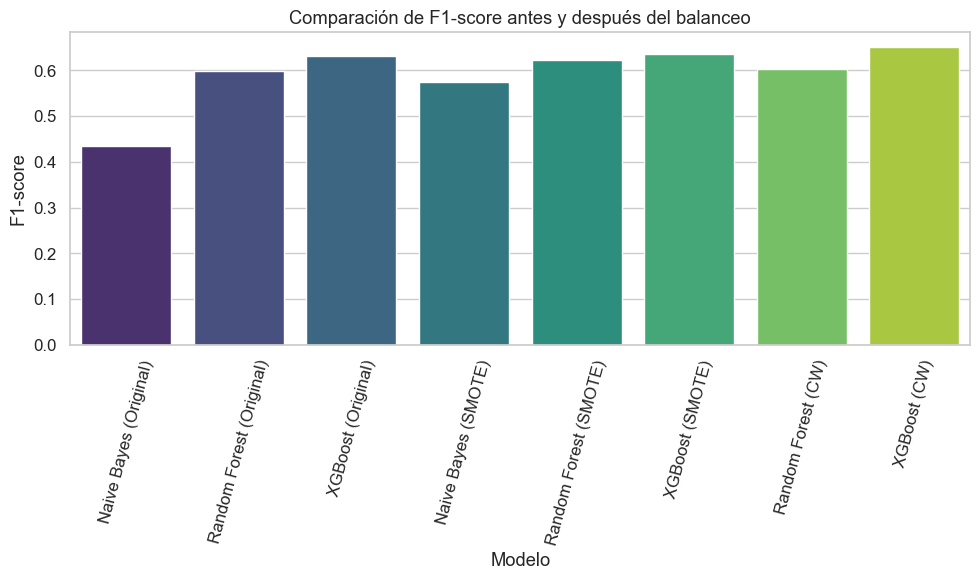

In [92]:
# Mostrar tabla comparativa final
display(df_resultados.sort_values(by='F1-score', ascending=False))

# Gráfico comparativo
plt.figure(figsize=(10,6))
sns.barplot(data=df_resultados, x='Modelo', y='F1-score', palette='viridis')
plt.xticks(rotation=75)
plt.title("Comparación de F1-score antes y después del balanceo")
plt.tight_layout()
plt.show()


## Análisis comparativo

1. **Impacto del balanceo en Naive Bayes**  
   - Al aplicar SMOTE, el modelo Naive Bayes incrementó notablemente su **F1-score** (de 0.434 a 0.574), indicando una mejora en la detección de la clase minoritaria.  
   - Sin embargo, el **Accuracy** disminuyó levemente, lo cual es esperable cuando se busca un mejor equilibrio entre clases.  
   - En general, el balanceo ayudó a Naive Bayes a ser más justo entre clases, aunque sigue siendo un modelo limitado frente a los demás.

2. **Comportamiento del Random Forest**  
   - Tanto con SMOTE como con `class_weight='balanced'`, Random Forest mantuvo un rendimiento sólido, con pequeñas variaciones entre técnicas.  
   - El **F1-score** aumentó con SMOTE, y el **AUC** mejoró ligeramente con `class_weight`.  
   - Esto demuestra que el modelo aprovecha bien ambas estrategias, aunque el beneficio marginal sugiere que el desbalance original no era severo.

3. **Dominio del modelo XGBoost**  
   - En todas las pruebas, **XGBoost** obtuvo los mejores resultados en **AUC** y **F1-score**, confirmando su robustez y capacidad para manejar datos moderadamente desbalanceados.  
   - Las variaciones entre SMOTE y `class_weight` fueron mínimas, pero `class_weight` ofreció un mejor F1-score (0.651), destacándose como la configuración más equilibrada y eficiente.


## A manera general

- Las técnicas de balanceo aplicadas (SMOTE y `class_weight='balanced'`) **lograron mejorar el rendimiento de los modelos en términos de F1-score**, es decir, en su capacidad para reconocer correctamente ambas clases.  
- **SMOTE** resultó útil a nivel académico, permitiendo observar cómo la generación sintética de muestras puede equilibrar los datos, aunque con un costo computacional más alto.  
- **El balanceo mediante `class_weight` fue más eficiente y estable**, mostrando mejoras similares sin requerir más memoria ni procesamiento adicional.  
- En conjunto, los resultados muestran que cuando el desbalance no es extremo, **ajustar los pesos de clase suele ser preferible a técnicas de sobremuestreo**.  
- Finalmente, **XGBoost con `class_weight='balanced'`** se posiciona como el modelo más competitivo en esta evaluación, combinando alta precisión con una excelente capacidad de discriminación entre clases.